In [1]:
# import important libraries

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib
matplotlib.use("Agg")  # remove this line if running interactively
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
# load data

In [5]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

In [6]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [7]:
df.tail()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0
1199,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,7,3,0


In [8]:
df.columns.tolist()

['age',
 'gender',
 'daily_social_media_hours',
 'platform_usage',
 'sleep_hours',
 'screen_time_before_sleep',
 'academic_performance',
 'physical_activity',
 'social_interaction_level',
 'stress_level',
 'anxiety_level',
 'addiction_level',
 'depression_label']

In [9]:
df.info

<bound method DataFrame.info of       age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0      14    male                       7.9      Instagram          7.4   
1      19  female                       1.9         TikTok          8.0   
2      17  female                       1.3      Instagram          7.6   
3      15    male                       7.4         TikTok          6.9   
4      15  female                       4.7           Both          4.9   
...   ...     ...                       ...            ...          ...   
1195   18  female                       6.8      Instagram          6.6   
1196   16    male                       2.3           Both          8.0   
1197   14  female                       1.7           Both          8.7   
1198   15    male                       3.9           Both          8.5   
1199   16  female                       4.7         TikTok          6.5   

      screen_time_before_sleep  academic_performance  physical_acti

In [10]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [11]:
num_cols = ["age", "daily_social_media_hours", "sleep_hours", "screen_time_before_sleep", "academic_performance", "physical_activity", "stress_level", "anxiety_level", "addiction_level"]
cat_cols = ["gender", "platform_usage", "social_interaction_level"]
target = "depression_label"

In [12]:
# structure & data quality

In [15]:
print("=" * 60)
print("shape:", df.shape)
print("\nDatatype:\n", df.dtypes)
print("\nMissing Values:\n", df.isna().sum())
print("\nduplicate rows:", df.duplicated().sum())
print("\nUnique values per column:\n", df.nunique())

shape: (1200, 13)

Datatype:
 age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

Missing Values:
 age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

duplicate rows: 0

Unique values per column:
 age                 

In [16]:
print("Numeric summary:", df[num_cols].describe().T)

Numeric summary:                            count       mean       std   min   25%    50%  \
age                       1200.0  15.928333  2.021947  13.0  14.0  16.00   
daily_social_media_hours  1200.0   4.536667  2.029599   1.0   2.8   4.50   
sleep_hours               1200.0   6.449417  1.442677   4.0   5.2   6.50   
screen_time_before_sleep  1200.0   1.740333  0.716660   0.5   1.1   1.80   
academic_performance      1200.0   2.990383  0.576758   2.0   2.5   2.99   
physical_activity         1200.0   1.014500  0.582185   0.0   0.5   1.00   
stress_level              1200.0   5.445833  2.903290   1.0   3.0   5.00   
anxiety_level             1200.0   5.636667  2.859453   1.0   3.0   6.00   
addiction_level           1200.0   5.565000  2.830627   1.0   3.0   6.00   

                            75%   max  
age                       18.00  19.0  
daily_social_media_hours   6.30   8.0  
sleep_hours                7.60   9.0  
screen_time_before_sleep   2.40   3.0  
academic_performance  

In [17]:
print("Categorical counts:")
for c in cat_cols:
    print(f"\n -- {c} --")
    print(df[c].value_counts())

Categorical counts:

 -- gender --
gender
male      615
female    585
Name: count, dtype: int64

 -- platform_usage --
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

 -- social_interaction_level --
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64


In [18]:
print("Target balance (depression_labels):")
print(df[target].value_counts())
print(df[target].value_counts(normalize=True))

Target balance (depression_labels):
depression_label
0    1169
1      31
Name: count, dtype: int64
depression_label
0    0.974167
1    0.025833
Name: proportion, dtype: float64


In [19]:
# outliers check via z-score (|z|>3)

In [20]:
print("Outliers per numeric columns:")
for c in num_cols:
    z = np.abs(stats.zscore(df[c]))
    print(f" {c}: {(z>3).sum()}")

Outliers per numeric columns:
 age: 0
 daily_social_media_hours: 0
 sleep_hours: 0
 screen_time_before_sleep: 0
 academic_performance: 0
 physical_activity: 0
 stress_level: 0
 anxiety_level: 0
 addiction_level: 0


In [21]:
# correlations

In [22]:
corr = df[num_cols + [target]].corr()
print("Correlation with target:")
print(corr[target].sort_values(ascending=False))

Correlation with target:
depression_label            1.000000
daily_social_media_hours    0.175201
stress_level                0.170474
anxiety_level               0.169566
age                         0.010973
academic_performance        0.001441
addiction_level            -0.013952
screen_time_before_sleep   -0.016502
physical_activity          -0.017598
sleep_hours                -0.190630
Name: depression_label, dtype: float64


In [23]:
# group comaprison: depressed vs non-depressed (Welch's t-test)

In [24]:
g1 = df[df[target]==1]
g0 = df[df[target]==0]

In [25]:
print("Group means by depression lable:")
print(df.groupby(target)[num_cols].mean().T)

Group means by depression lable:
depression_label                  0          1
age                       15.924722  16.064516
daily_social_media_hours   4.478785   6.719355
sleep_hours                6.494183   4.761290
screen_time_before_sleep   1.742258   1.667742
academic_performance       2.990248   2.995484
physical_activity          1.016168   0.951613
stress_level               5.365269   8.483871
anxiety_level              5.557742   8.612903
addiction_level            5.571429   5.322581


In [28]:
print("WELCH'S T-TESTS (depressed vs not):")
for c in num_cols:
    t, p = stats.ttest_ind(g1[c], g0[c], equal_var=False)
    sig = "***" if p<0.001 else ("*" if p<0.05 else "")
    print(f" {c:28s} t={t:7.2f} p={p:.4f} {sig}")

WELCH'S T-TESTS (depressed vs not):
 age                          t=   0.37 p=0.7122 
 daily_social_media_hours     t=  11.71 p=0.0000 ***
 sleep_hours                  t= -15.75 p=0.0000 ***
 screen_time_before_sleep     t=  -0.53 p=0.5982 
 academic_performance         t=   0.05 p=0.9597 
 physical_activity            t=  -0.62 p=0.5382 
 stress_level                 t=  13.40 p=0.0000 ***
 anxiety_level                t=  14.77 p=0.0000 ***
 addiction_level              t=  -0.45 p=0.6539 


In [29]:
# categorical association (chi-square test of independence)

In [30]:
print("Chi-square tests (categorical vs depression_labels):")
for c in cat_cols:
    ct = pd.crosstab(df[c], df[target])
    chi2, p, dof, exxp = stats.chi2_contingency(ct)
    print(f"\n -- {c} -- chi2={chi2:.2f}, p={p:.4f}")
    print(ct)
    print("Depression rate by group:")
    print(df.groupby(c)[target].mean())

Chi-square tests (categorical vs depression_labels):

 -- gender -- chi2=0.26, p=0.6135
depression_label    0   1
gender                   
female            568  17
male              601  14
Depression rate by group:
gender
female    0.029060
male      0.022764
Name: depression_label, dtype: float64

 -- platform_usage -- chi2=0.45, p=0.7966
depression_label    0   1
platform_usage           
Both              382   9
Instagram         401  10
TikTok            386  12
Depression rate by group:
platform_usage
Both         0.023018
Instagram    0.024331
TikTok       0.030151
Name: depression_label, dtype: float64

 -- social_interaction_level -- chi2=0.46, p=0.7957
depression_label            0   1
social_interaction_level         
high                      359  10
low                       406   9
medium                    404  12
Depression rate by group:
social_interaction_level
high      0.027100
low       0.021687
medium    0.028846
Name: depression_label, dtype: float64


In [31]:
# binned depression rates (threshold effects)

In [37]:
df["sm_bin"] = pd.cut(
    df["daily_social_media_hours"], bins=[0,2,4,6,8], 
    labels=["0-2h", "2-4h", "4-6h", "6-8h"], include_lowest=True,
)

In [38]:
df["sleep_bin"] = pd.cut(
    df["sleep_hours"], bins=[0, 5, 6, 7, 8, 10],
    labels=["<=5h", "5-6h", "6-7h", "7-8h", "8h+"],
)

In [39]:
print("Depression rate by Social Media use bin:")
print(df.groupby("sm_bin", observed=True)[target].agg(["mean", "count"]))

Depression rate by Social Media use bin:
            mean  count
sm_bin                 
0-2h    0.000000    172
2-4h    0.000000    356
4-6h    0.026786    336
6-8h    0.065476    336


In [41]:
print("Depression rate by Sleep bin:")
print(df.groupby("sleep_bin", observed=True)[target].agg(["mean", "count"]))

Depression rate by Sleep bin:
               mean  count
sleep_bin                 
<=5h       0.083333    264
5-6h       0.037975    237
6-7h       0.000000    245
7-8h       0.000000    248
8h+        0.000000    206


In [43]:
# visualization

In [50]:
# distribution grid for all numeric variables
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, c in zip(axes.flat, num_cols):
    sns.histplot(df[c], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(c)
plt.tight_layout()
plt.savefig("dist_grid.png", dpi=130)

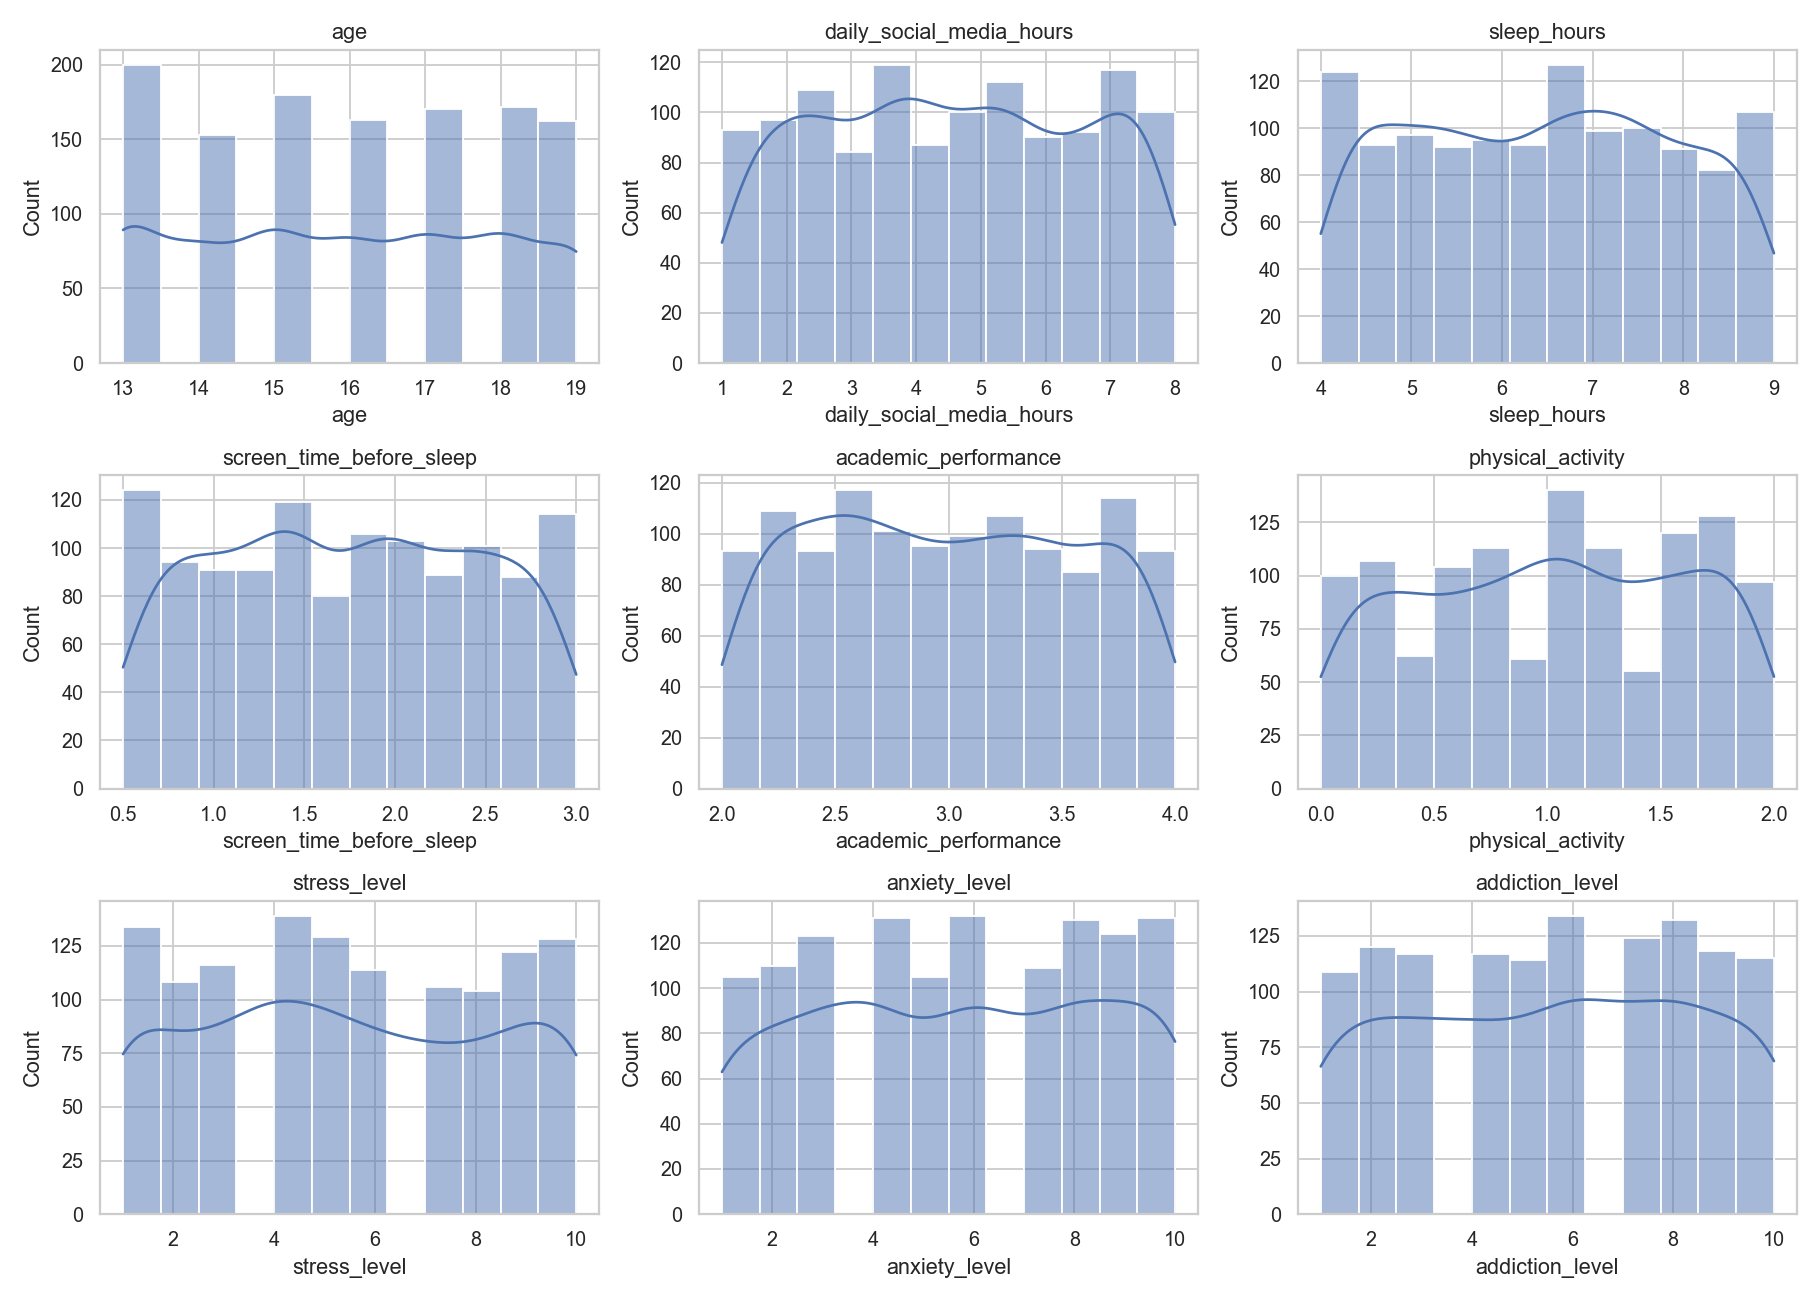

In [52]:
from IPython.display import Image, display
display(Image(filename="dist_grid.png"))

In [53]:
# correlation heatmap
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("correlation Matrix")
plt.tight_layout()
plt.savefig("corr_heatmap.png", dpi=130)
plt.close()

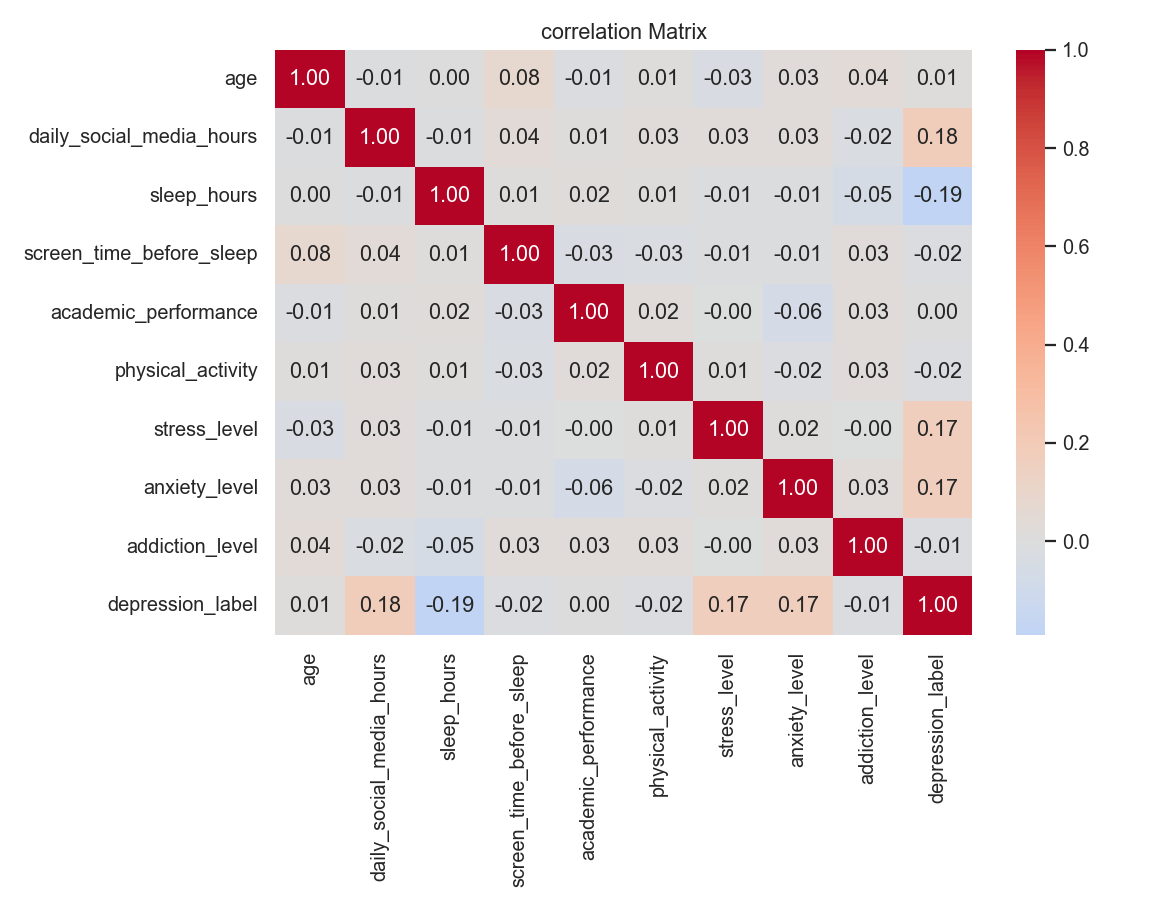

In [54]:
from IPython.display import Image, display
display(Image(filename="corr_heatmap.png"))

In [57]:
#Boxplots of key variables by depression label
key_vars = ["sleep_hours", "stress_level", "anxiety_level", "daily_social_media_hours"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, c in zip(axes, key_vars):
    sns.boxplot(x=target, y=c, hue=target, data=df, ax=ax,
                palette=["#55A868", "#C44E52"], legend=False)
    ax.set_xlabel("Depression Label")
plt.tight_layout()
plt.savefig("boxplots_depression.png", dpi=130)
plt.close()

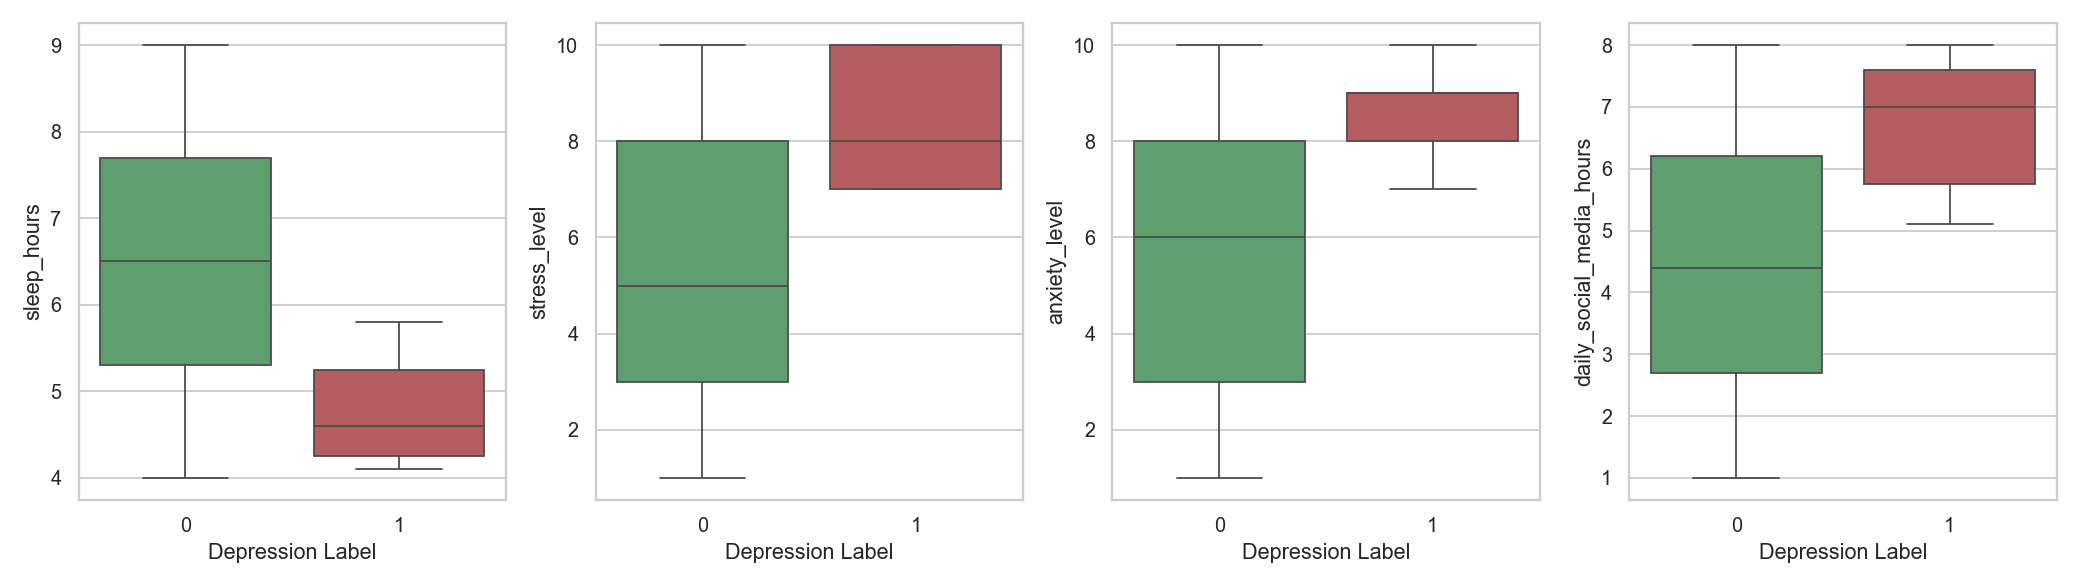

In [58]:
display(Image(filename="boxplots_depression.png"))

In [61]:
# Depression rate by sleep bin & social media bin
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sm_rate = df.groupby("sm_bin", observed=True)[target].mean() * 100
sm_rate.plot(kind="bar", ax=axes[0], color="#DD8452")
axes[0].set_ylabel("Depression rate (%)")
axes[0].set_title("Depression Rate by Daily Social Media Use")
axes[0].tick_params(axis="x", rotation=0)
 
sl_rate = df.groupby("sleep_bin", observed=True)[target].mean() * 100
sl_rate.plot(kind="bar", ax=axes[1], color="#64B5CD")
axes[1].set_ylabel("Depression rate (%)")
axes[1].set_title("Depression Rate by Sleep Hours")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("rate_bins.png", dpi=130)
plt.close()

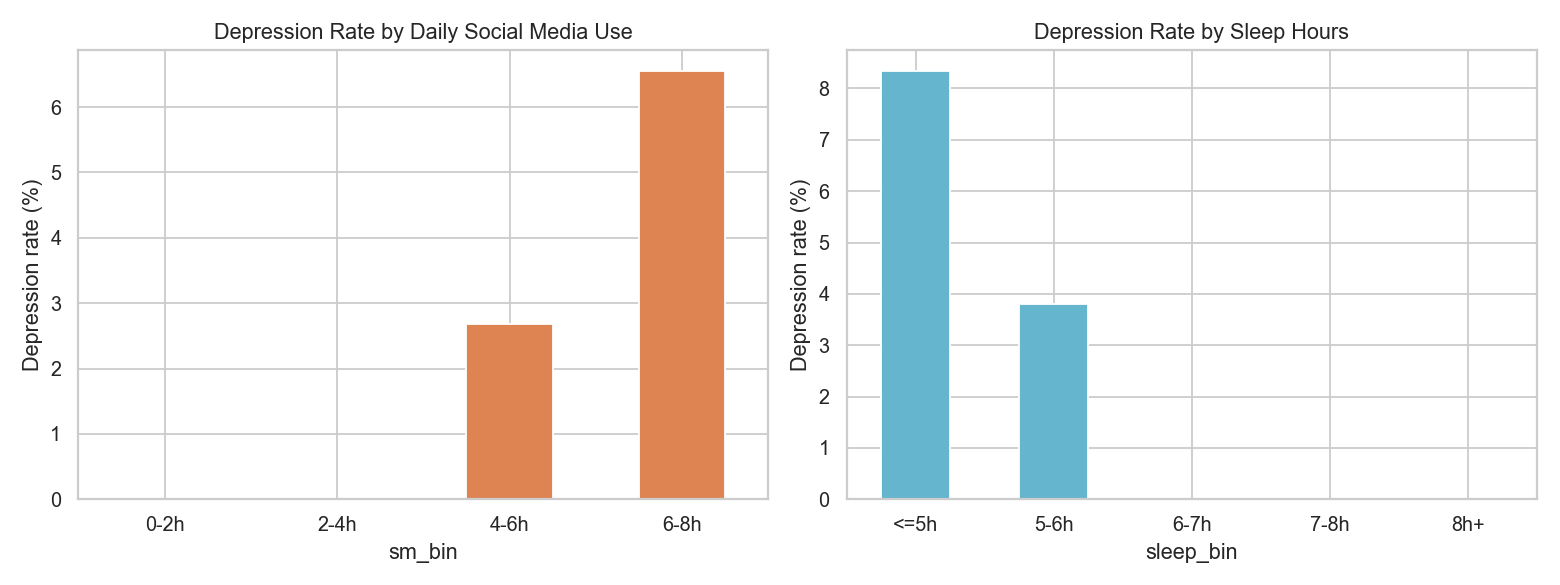

In [63]:
display(Image(filename="rate_bins.png"))

In [65]:
# Scatter: social media hours vs sleep hours, colored by depression
plt.figure(figsize=(7, 5.5))
sns.scatterplot(
    data=df, x="daily_social_media_hours", y="sleep_hours", hue=target,
    palette=["#4C72B0", "#C44E52"], alpha=0.6, s=35,
)
plt.title("Social Media Hours vs Sleep Hours")
plt.tight_layout()
plt.savefig("scatter_sm_sleep.png", dpi=130)
plt.close()

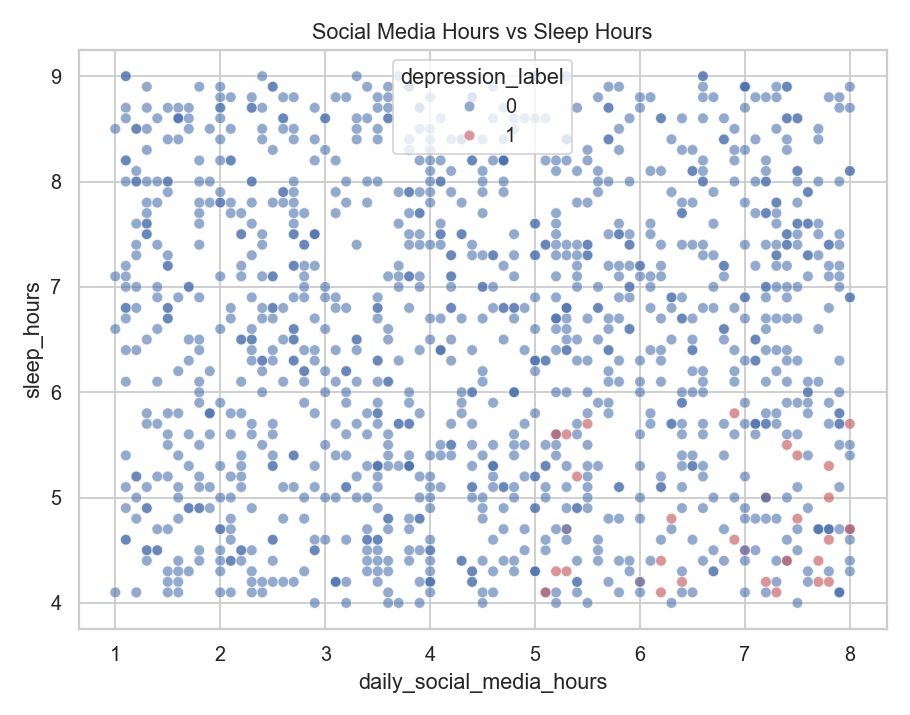

In [66]:
display(Image(filename="scatter_sm_sleep.png"))

In [70]:
# Categorical breakdown vs depression rate
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, c in zip(axes, cat_cols):
    rate = df.groupby(c)[target].mean() * 100
    rate.plot(kind="bar", ax=ax, color="#8172B2")
    ax.set_ylabel("Depression rate (%)")
    ax.set_title(c)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("cat_rates.png", dpi=130)
plt.close()

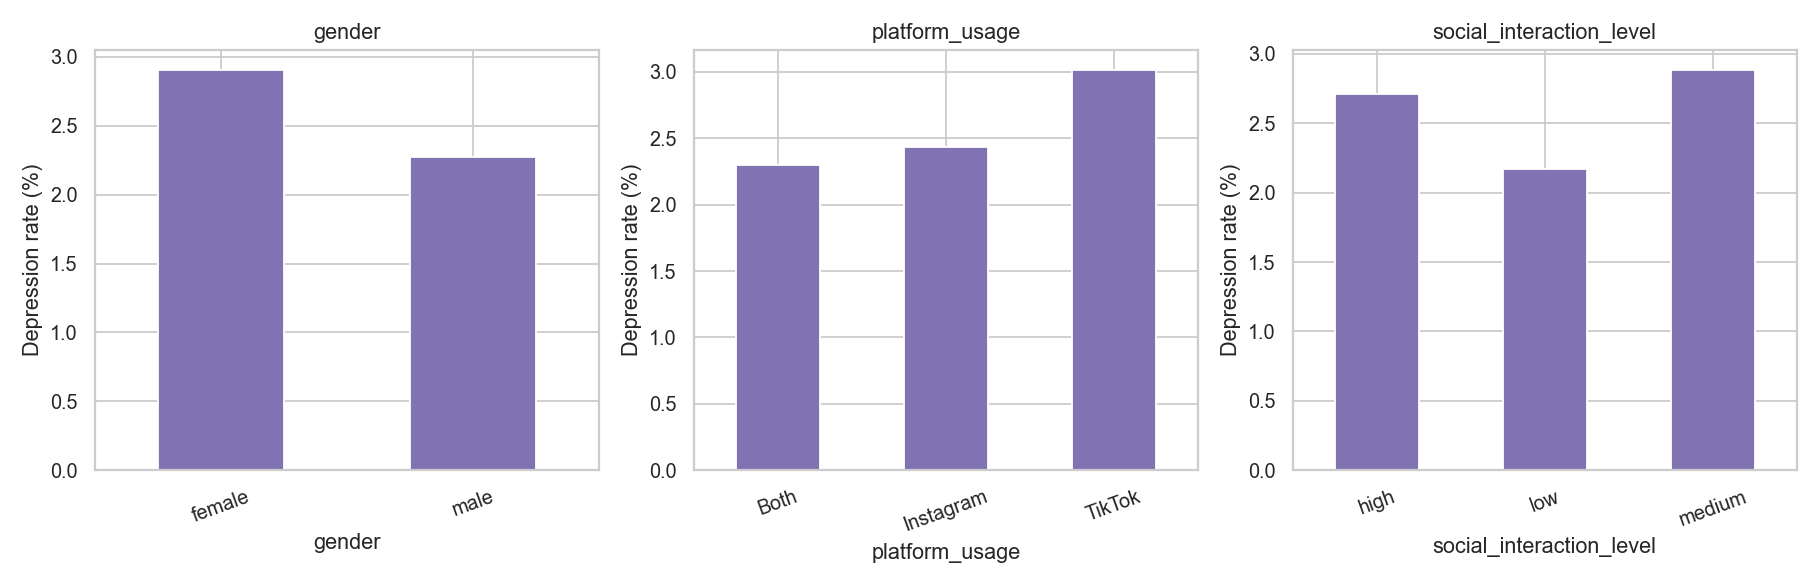

In [71]:
display(Image(filename="cat_rates.png"))

In [72]:
print("\nDone. Charts saved: dist_grid.png, corr_heatmap.png, "
      "boxplots_depression.png, rate_bins.png, scatter_sm_sleep.png, cat_rates.png")


Done. Charts saved: dist_grid.png, corr_heatmap.png, boxplots_depression.png, rate_bins.png, scatter_sm_sleep.png, cat_rates.png
